Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Data Collection and Analysis

PIMA Diabetes Dataset

In [2]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv('../dataset/diabetes.csv') 

In [3]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# number of rows and Columns in this dataset
diabetes_dataset.shape

(768, 9)

In [5]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
diabetes_dataset['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

0 --> Non-Diabetic

1 --> Diabetic

In [8]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


C:\Users\User\AppData\Local\Temp\ipykernel_4384\1397599666.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(diabetes_dataset[diabetes_dataset['Outcome'] == 0]['Glucose'], label='No Diabetes', shade=True, color='blue')
C:\Users\User\AppData\Local\Temp\ipykernel_4384\1397599666.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(diabetes_dataset[diabetes_dataset['Outcome'] == 1]['Glucose'], label='Diabetes', shade=True, color='red')


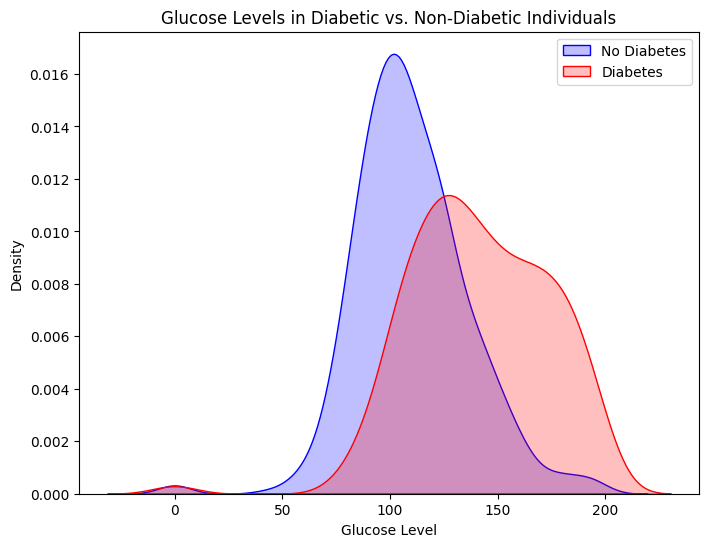

In [9]:
plt.figure(figsize=(8, 6))
sns.kdeplot(diabetes_dataset[diabetes_dataset['Outcome'] == 0]['Glucose'], label='No Diabetes', shade=True, color='blue')
sns.kdeplot(diabetes_dataset[diabetes_dataset['Outcome'] == 1]['Glucose'], label='Diabetes', shade=True, color='red')
plt.xlabel('Glucose Level')
plt.ylabel('Density')
plt.title('Glucose Levels in Diabetic vs. Non-Diabetic Individuals')
plt.legend()
plt.show()


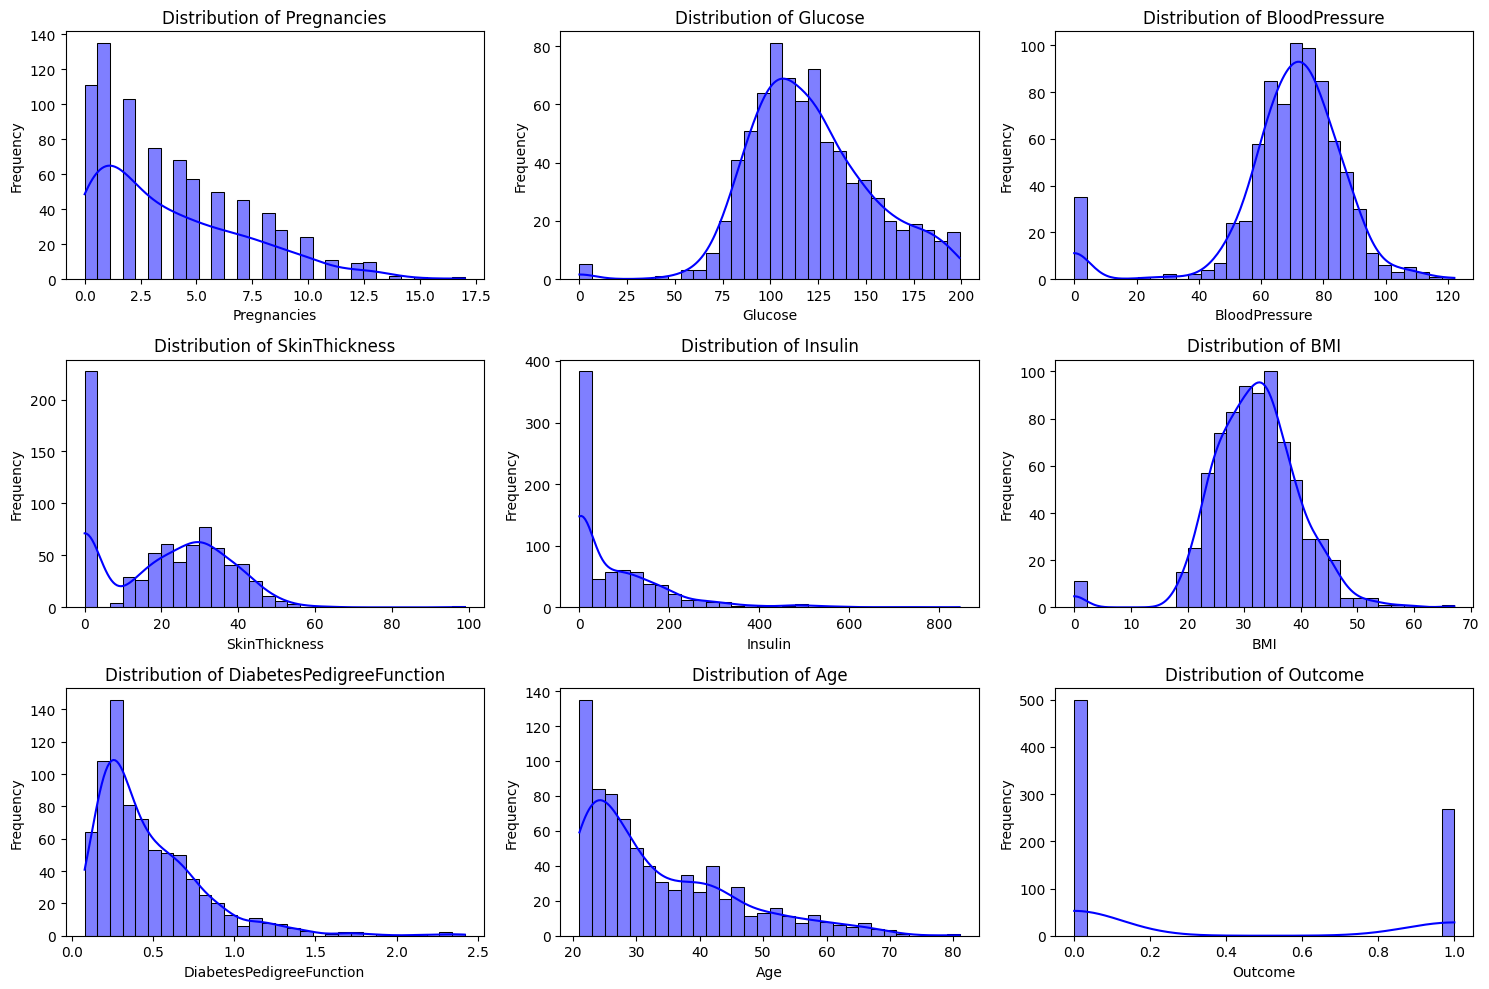

In [10]:


# Set figure size
plt.figure(figsize=(15, 10))

# Create histograms for all features
for i, col in enumerate(diabetes_dataset.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(diabetes_dataset[col], kde=True, bins=30, color='blue')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_4384\2836116217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Outcome', y='Age', data=diabetes_dataset, palette='Set2')


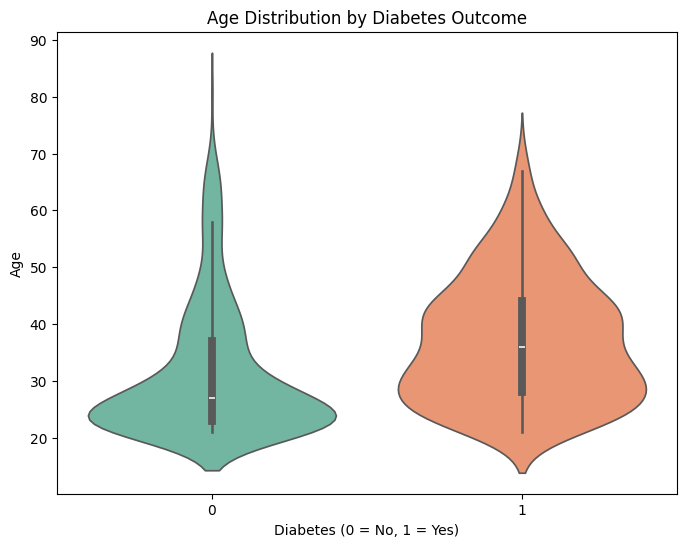

In [11]:
plt.figure(figsize=(8, 6))
sns.violinplot(x='Outcome', y='Age', data=diabetes_dataset, palette='Set2')
plt.xlabel('Diabetes (0 = No, 1 = Yes)')
plt.ylabel('Age')
plt.title('Age Distribution by Diabetes Outcome')
plt.show()


In [12]:
# separating the data and labels
X = diabetes_dataset.drop(columns = 'Outcome', axis=1)
Y = diabetes_dataset['Outcome']

In [13]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [14]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


Train Test Split

In [15]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=2)

In [16]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Training the Model

In [17]:
classifier = svm.SVC(kernel='linear')

In [18]:
#training the support vector Machine Classifier
classifier.fit(X_train, Y_train)

SVC(kernel='linear')

In [19]:
import plotly.express as px

In [20]:
from sklearn.neighbors import KNeighborsClassifier

In [21]:
accuracy_list = []
k_values = range(1, 21)

In [22]:
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    accuracy_list.append(accuracy)

In [23]:
fig=px.line(x=k_values,y=accuracy_list, template='plotly_dark')
fig.update_layout(
    title='Accuracy for different k values',
    xaxis_title='k value',
    yaxis_title='Accuracy'
) 



fig.show()


In [24]:
k=6
knn= KNeighborsClassifier(n_neighbors = k)

In [25]:
p={'n_neighbors':np.arange(1,235),
        'p':np.arange(1,3),
        'weights':['uniform','distance'],
        'algorithm':['auto','ball_tree','kd_tree','brute']
       }

In [26]:
from sklearn.model_selection import GridSearchCV


knn_csv= GridSearchCV(knn,p,cv=5)

In [27]:
knn_csv.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=6),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  7...
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182,
       183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195,
       196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208,
       209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,
       222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234]),
                         'p': array([1, 2]),
                         'weights': ['uniform', 'distance']})

In [28]:
print("the best parametrs are ",knn_csv.best_params_)
print("the accuracy is : ",knn_csv.best_score_)

the best parametrs are  {'algorithm': 'auto', 'n_neighbors': 21, 'p': 1, 'weights': 'distance'}
the accuracy is :  0.7686925229908037


Model Evaluation

Accuracy Score

In [29]:
a= knn_csv.score(X_test,Y_test)

In [30]:
knn_pre=knn_csv.predict(X_test)

In [31]:
from sklearn.metrics import confusion_matrix


def plot_confusion_matrix(y,X_test_prediction):
    

    cm = confusion_matrix(y, X_test_prediction)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    # ax.xaxis.set_ticklabels(['non-cancerous', 'cancer']); ax.yaxis.set_ticklabels(['non-cancerous', 'cancer']) 
    plt.show() 

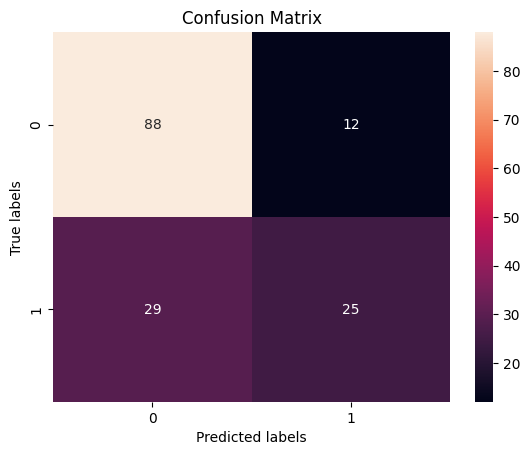

In [32]:
plot_confusion_matrix(Y_test,knn_pre)

# Extreme Gradient Boosting (XGBoost)

In [33]:
from xgboost import XGBClassifier 
xgb = XGBClassifier()

In [34]:
xg_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}


xggrid_search = GridSearchCV(xgb, xg_grid,scoring='accuracy', cv=5, verbose=2, n_jobs=-1)

In [35]:
xggrid_search.fit(X_train, Y_train)

Fitting 5 folds for each of 972 candidates, totalling 4860 fits


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, 0.2],
                         'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'min_child_weight': [1, 3, 5],
                         'n_estimators': [100, 200, 300],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy', verbose=2)

In [36]:
xg_acc=xggrid_search.score(X_test,Y_test)

In [37]:
xg_pre= xggrid_search.predict(X_test)

In [38]:
from sklearn.metrics import confusion_matrix,classification_report

In [39]:
confusion= confusion_matrix(Y_test,xg_pre)
clf_report= classification_report(Y_test,xg_pre)




print("the accuracy score is ",xg_acc)
print("the confusion matrix is \n",confusion)
print("the classification report is \n", clf_report)

the accuracy score is  0.7272727272727273
the confusion matrix is 
 [[90 10]
 [32 22]]
the classification report is 
               precision    recall  f1-score   support

           0       0.74      0.90      0.81       100
           1       0.69      0.41      0.51        54

    accuracy                           0.73       154
   macro avg       0.71      0.65      0.66       154
weighted avg       0.72      0.73      0.71       154



In [40]:
def plot_confusion_matrix(y,X_test_prediction):
    

    cm = confusion_matrix(y, X_test_prediction)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    # ax.xaxis.set_ticklabels(['non-cancerous', 'cancer']); ax.yaxis.set_ticklabels(['non-cancerous', 'cancer']) 
    plt.show() 

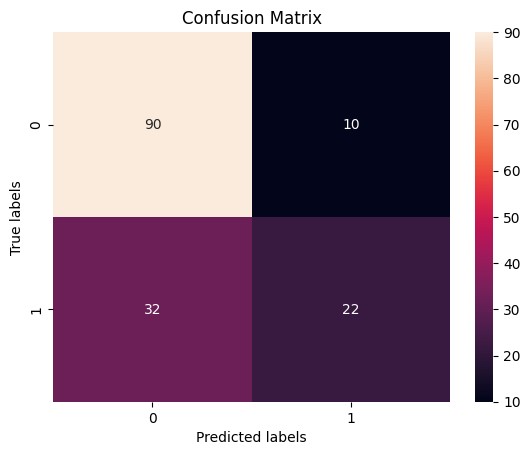

In [41]:
plot_confusion_matrix(Y_test,xg_pre)

Making a Predictive System

In [42]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = classifier.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[1]
The person is diabetic


g:\Multiple-Disease-prediction-using-machine-learning-main\venv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Saving the trained model

In [43]:
import pickle

In [44]:
filename = 'diabetes_model.sav'
pickle.dump(classifier, open(filename, 'wb'))

In [45]:
# loading the saved model
loaded_model = pickle.load(open('diabetes_model.sav', 'rb'))

In [46]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = loaded_model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[1]
The person is diabetic


g:\Multiple-Disease-prediction-using-machine-learning-main\venv\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [47]:
for column in X.columns:
  print(column)

Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age


In [48]:
import pickle
import os

os.makedirs('saved_models', exist_ok=True)

filename = 'saved_models/diabetes_model.sav'

pickle.dump(classifier, open(filename, 'wb'))

print("Model Saved Successfully")

Model Saved Successfully
